In [23]:
# === Cloudy spectra overlay by Teff, showing fsed dependence ===
# Drop this cell anywhere (e.g., in your bd_spectravis.ipynb).

import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt


In [24]:
clouddir   = r"C:\Users\Alex\Desktop\Picaso\NN_project\outputs\\"  # <- folder with cloudy .npy files
TEFF_STR   = "1434.6237805136786"  # <-- exact Teff string in filenames (after the 't')
WAV_WINDOW = (0.5, 15.0)          # set to None for full range

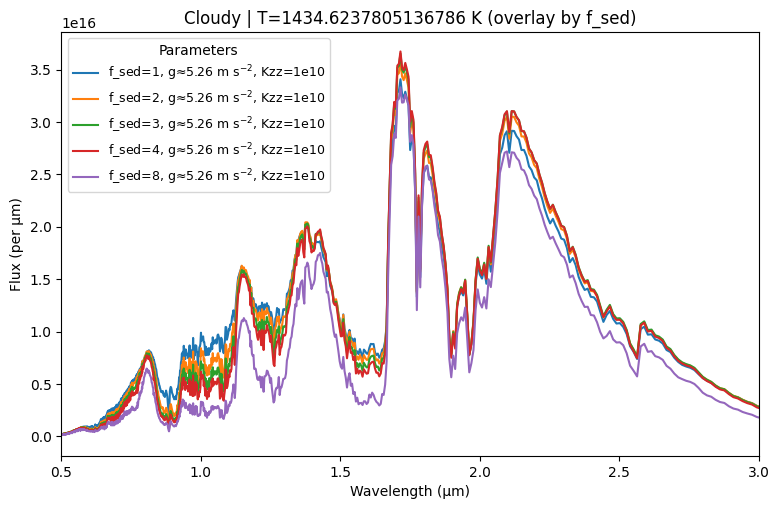

In [25]:
# list .npy files that contain this exact Teff substring "t<TEFF_STR>"
cloudy_files = [f for f in os.listdir(clouddir)
                if f.endswith(".npy") and f"t{TEFF_STR}" in f]

if not cloudy_files:
    raise SystemExit(f"No files found in {clouddir} with exact Teff 't{TEFF_STR}'.")

# small helper to make a nice label from filename
def make_label(fname: str) -> str:
    parts = []
    m = re.search(r"f([0-9.eE+\-]+)", fname)
    if m: parts.append(f"f_sed={float(m.group(1)):g}")
    m = re.search(r"logg([0-9.eE+\-]+)", fname)
    if m: parts.append(f"log g={float(m.group(1)):.2f} (cgs)")
    else:
        m = re.search(r"(?<!log)g([0-9.eE+\-]+)", fname)  # 'g' but not 'logg'
        if m: parts.append(f"g≈{float(m.group(1)):.2f} m s$^{{-2}}$")
    m = re.search(r"k([0-9.eE+\-]+)", fname)
    if m: parts.append(f"Kzz={m.group(1)}")
    return ", ".join(parts) if parts else fname

# set up plot
plt.figure(figsize=(9, 5.5))

# sort by fsed if present so legend is orderly
def _fsed_key(fname):
    m = re.search(r"f([0-9.eE+\-]+)", fname)
    return float(m.group(1)) if m else np.inf

for fname in sorted(cloudy_files, key=_fsed_key):
    path = os.path.join(clouddir, fname)

    # --- load 1-D flux (per cm^-1) ---
    flux_sigma = np.load(path, allow_pickle=True)  # same as your cloud-free case

    # --- build wavenumber grid to match array length (333.3 -> 20000 cm^-1) ---
    wnmin, wnmax = 333.3, 20000.0
    wn = np.linspace(wnmax, wnmin, flux_sigma.size)  # descending, like your snippet

    # --- convert to wavelength (μm) and flux per μm (Jacobian) ---
    wl = 1e4 / wn                  # μm
    flux_lambda = flux_sigma * (1e4 / wl**2)

    # --- sort by ascending wavelength (for pretty plotting) ---
    idx = np.argsort(wl)
    wl_val = wl[idx]
    fl_val = flux_lambda[idx]

    # --- optional wavelength window ---
    if WAV_WINDOW is not None:
        wmin, wmax = WAV_WINDOW
        mask = (wl_val >= wmin) & (wl_val <= wmax)
    else:
        mask = slice(None)

    # --- plot ---
    plt.plot(wl_val[mask], fl_val[mask], lw=1.5, label=make_label(fname))

# title using the *exact* Teff string the user chose
plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux (per μm)")
plt.title(f"Cloudy | T={TEFF_STR} K (overlay by f_sed)")
plt.xlim(0.5, 3.0)
plt.legend(title="Parameters", fontsize=9)
plt.show()